# Lab 05 — Robotics: Sensor-to-Action Control

**Worked Python solution.** The supplied file contains **24 ultrasonic sensor readings plus one action label**. To keep the controller interpretable, feature selection is performed on training data only and the four most informative sensors are used by a shallow decision tree. The tree is exported as explicit if–then rules. A random forest using all 24 sensors is included only as a reference ceiling.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "all_datasets").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the course project.")
ROOT=find_project_root()
print("Project root:",ROOT)

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

RESULTS=ROOT/"results"/"lab05"; RESULTS.mkdir(parents=True,exist_ok=True)
columns=[f"US{i:02d}" for i in range(24)]+["action"]
df=pd.read_csv(ROOT/"all_datasets"/"lab05-sensor_readings_24.csv",header=None,names=columns)
print("Shape:",df.shape)
display(df.action.value_counts().rename("count").to_frame())

Project root: /mnt/data/ai_course_final/ARTIFICIAL INTELLIGENCE


Shape: (5456, 25)


,count
action,
Move-Forward,2205
Sharp-Right-Turn,2097
Slight-Right-Turn,826
Slight-Left-Turn,328


## 1. Fixed split and training-only feature selection

In [2]:
indices=np.arange(len(df)); train_idx,test_idx=train_test_split(indices,test_size=.30,random_state=42,stratify=df.action)
split=pd.DataFrame({"row_id":indices,"split":"train"}); split.loc[test_idx,"split"]="test"; split.to_csv(RESULTS/"split.csv",index=False)
X=df[columns[:-1]]; y=df.action
mi=mutual_info_classif(X.iloc[train_idx],y.iloc[train_idx],random_state=42)
selected=X.columns[np.argsort(mi)[::-1][:4]].tolist()
feature_table=pd.DataFrame({"sensor":X.columns,"mutual_information":mi}).sort_values("mutual_information",ascending=False)
feature_table.to_csv(RESULTS/"feature_scores.csv",index=False)
print("Selected sensors:",selected)
display(feature_table.head(8).round(3))

Selected sensors: ['US14', 'US17', 'US18', 'US13']


,sensor,mutual_information
14,US14,0.596
17,US17,0.508
18,US18,0.452
13,US13,0.417
19,US19,0.414
22,US22,0.386
5,US05,0.376
12,US12,0.375


## 2. Tune the interpretable rule controller on training data only

A shallow decision tree is a deterministic set of threshold rules. Depth is chosen using an internal validation split from the training partition; the final test set remains untouched.

In [3]:
subtrain,val=train_test_split(train_idx,test_size=.20,random_state=42,stratify=y.iloc[train_idx])
validation=[]
for depth in [2,3,4,5,6]:
    m=DecisionTreeClassifier(max_depth=depth,min_samples_leaf=20,class_weight="balanced",random_state=42)
    m.fit(X.loc[subtrain,selected],y.iloc[subtrain])
    score=f1_score(y.iloc[val],m.predict(X.loc[val,selected]),average="macro")
    validation.append((depth,score))
val_df=pd.DataFrame(validation,columns=["max_depth","validation_macro_f1"]); display(val_df.round(3))
best_depth=int(val_df.loc[val_df.validation_macro_f1.idxmax(),"max_depth"])
rule_model=DecisionTreeClassifier(max_depth=best_depth,min_samples_leaf=20,class_weight="balanced",random_state=42).fit(X.loc[train_idx,selected],y.iloc[train_idx])
print("Selected depth:",best_depth)
print(export_text(rule_model,feature_names=selected))

,max_depth,validation_macro_f1
0,2,0.463
1,3,0.826
2,4,0.872
3,5,0.887
4,6,0.883


Selected depth: 5
|--- US14 <= 0.90
|   |--- class: Sharp-Right-Turn
|--- US14 >  0.90
|   |--- US18 <= 1.00
|   |   |--- US18 <= 0.50
|   |   |   |--- US13 <= 1.20
|   |   |   |   |--- class: Sharp-Right-Turn
|   |   |   |--- US13 >  1.20
|   |   |   |   |--- US18 <= 0.50
|   |   |   |   |   |--- class: Slight-Right-Turn
|   |   |   |   |--- US18 >  0.50
|   |   |   |   |   |--- class: Slight-Right-Turn
|   |   |--- US18 >  0.50
|   |   |   |--- US13 <= 0.90
|   |   |   |   |--- class: Sharp-Right-Turn
|   |   |   |--- US13 >  0.90
|   |   |   |   |--- US17 <= 0.49
|   |   |   |   |   |--- class: Slight-Right-Turn
|   |   |   |   |--- US17 >  0.49
|   |   |   |   |   |--- class: Move-Forward
|   |--- US18 >  1.00
|   |   |--- US17 <= 0.90
|   |   |   |--- US17 <= 0.79
|   |   |   |   |--- US13 <= 1.41
|   |   |   |   |   |--- class: Move-Forward
|   |   |   |   |--- US13 >  1.41
|   |   |   |   |   |--- class: Move-Forward
|   |   |   |--- US17 >  0.79
|   |   |   |   |--- class: Slig

## 3. Reference model and held-out test evaluation

,model,accuracy,macro_precision,macro_recall,macro_f1
0,Interpretable rule tree,0.923,0.879,0.921,0.895
1,Random-forest reference,0.995,0.993,0.992,0.992


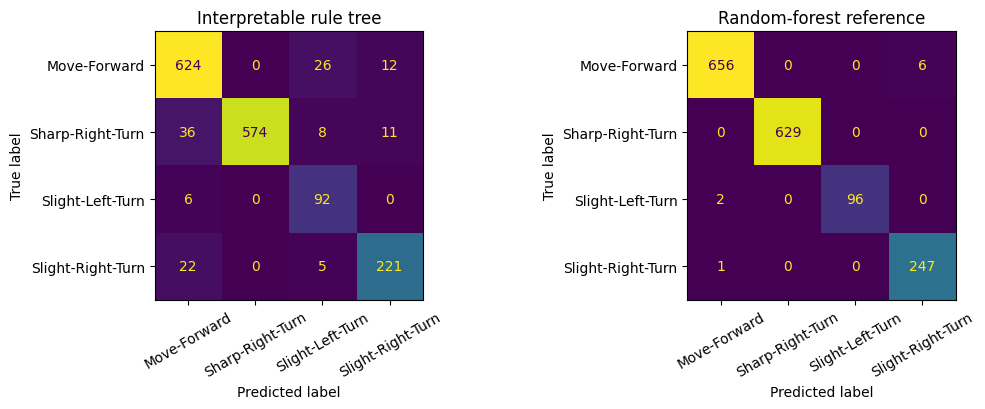

In [4]:
reference=RandomForestClassifier(n_estimators=200,min_samples_leaf=2,class_weight="balanced_subsample",random_state=42,n_jobs=-1).fit(X.iloc[train_idx],y.iloc[train_idx])
models={"Interpretable rule tree":(rule_model,X.loc[test_idx,selected]),"Random-forest reference":(reference,X.iloc[test_idx])}
metrics=[]; predictions={}
for name,(model,XX) in models.items():
    pred=model.predict(XX); predictions[name]=pred
    p,r,f,_=precision_recall_fscore_support(y.iloc[test_idx],pred,average="macro",zero_division=0)
    metrics.append({"model":name,"accuracy":accuracy_score(y.iloc[test_idx],pred),"macro_precision":p,"macro_recall":r,"macro_f1":f})
metrics=pd.DataFrame(metrics); metrics.to_csv(RESULTS/"metrics.csv",index=False); display(metrics.round(3))

labels=sorted(y.unique()); fig,axes=plt.subplots(1,2,figsize=(11,4.2))
for ax,(name,pred) in zip(axes,predictions.items()):
    ConfusionMatrixDisplay(confusion_matrix(y.iloc[test_idx],pred,labels=labels),display_labels=labels).plot(ax=ax,colorbar=False,xticks_rotation=30)
    ax.set_title(name)
fig.tight_layout(); fig.savefig(RESULTS/"confusion_matrices.png",dpi=160); plt.show()

In [5]:
rule_pred=predictions["Interpretable rule tree"]
per_class=pd.DataFrame(precision_recall_fscore_support(y.iloc[test_idx],rule_pred,labels=labels,zero_division=0)[:3],index=["precision","recall","f1"],columns=labels).T
per_class.to_csv(RESULTS/"rule_per_class.csv")
display(per_class.round(3))
print("Hardest action by recall:",per_class["recall"].idxmin())

,precision,recall,f1
Move-Forward,0.907,0.943,0.924
Sharp-Right-Turn,1.000,0.913,0.954
Slight-Left-Turn,0.702,0.939,0.803
Slight-Right-Turn,0.906,0.891,0.898


Hardest action by recall: Slight-Right-Turn


## 4. Noise robustness

,noise_fraction_of_train_sd,macro_f1
0,0.00,0.895
1,0.02,0.851
2,0.05,0.798
3,0.10,0.688


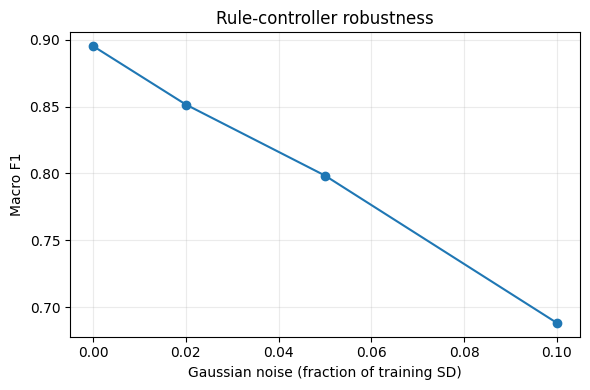

In [6]:
rng=np.random.default_rng(42); std=X.iloc[train_idx][selected].std().to_numpy(); base=X.loc[test_idx,selected].to_numpy(float)
noise_rows=[]
for pct in [0,.02,.05,.10]:
    noisy=base.copy()
    if pct>0: noisy+=rng.normal(0,pct*std,size=noisy.shape)
    pred=rule_model.predict(pd.DataFrame(noisy,columns=selected))
    noise_rows.append({"noise_fraction_of_train_sd":pct,"macro_f1":f1_score(y.iloc[test_idx],pred,average="macro")})
noise=pd.DataFrame(noise_rows); noise.to_csv(RESULTS/"noise_robustness.csv",index=False); display(noise.round(3))
ax=noise.plot(x="noise_fraction_of_train_sd",y="macro_f1",marker="o",legend=False,figsize=(6,4)); ax.set(xlabel="Gaussian noise (fraction of training SD)",ylabel="Macro F1",title="Rule-controller robustness"); ax.grid(alpha=.25); plt.tight_layout(); plt.savefig(RESULTS/"noise_robustness.png",dpi=160); plt.show()

## Worked interpretation

The four-sensor shallow tree is a strong **interpretable controller**: its thresholds can be inspected and translated directly into if–then logic. The all-sensor random forest performs substantially better, showing the accuracy cost of aggressive simplification. Noise testing also reveals that the rule controller degrades as sensor uncertainty increases.

Offline classification accuracy is not the same as safe robot control. Real deployment adds sequential feedback, actuator delay, obstacle geometry, sensor failure, and safety constraints. The classifier should therefore be viewed as a perception/control policy prototype rather than deployment-ready autonomy.